In [2]:
# =========================================================
# 1) IMPORTS
# =========================================================
%load_ext autoreload
%autoreload 2

import os
import glob
from pathlib import Path
import sys
import pyarrow
import pandas as pd
import shap
import matplotlib.pyplot as plt


PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

from src.repository.parquet_repository import ParquetRepository
from src.models.LightGBMRegressorBaseLine import LightGBMRegressorBaseLine
from src.models.LightGBMRegressorAnomaly import LightGBMRegressorAnomaly
from src.visualization.ModelsMetricsReporter import ModelsMetricsReporter
from src.XAI.LightGBMShapInterpreter import LightGBMShapInterpreter
from src.config.config import DATA_PROCESSED, DATA_FEATURES, MODELS_BASELINE,MODELS_METRICS

from src.XAI.LightGBMShapInterpreter_updated import LightGBMShapInterpreterU
from src.models.IsolationForest_updated import IsolationForestAnalyzer

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# =========================================================
# 2) EXEMPLO DE DADOS ESPERADOS
# =========================================================
# df_test_pred -> dataframe final de teste com:
# - features usadas no modelo
# - y_true (valor real)
# - pred_baseline
# - pred_hybrid
# - anomaly_score
# - anomaly_flag
#
# Ajuste os nomes abaixo se no seu projeto estiverem diferentes.

TARGET_COL = "quantity_sum"          # valor real
BASELINE_PRED_COL = "pred_baseline"  # predição baseline
HYBRID_PRED_COL = "pred_hybrid"      # predição modelo híbrido

In [4]:
repo = ParquetRepository(DATA_FEATURES)

In [5]:
df_features = repo.load("beverage_sales_feature.parquet")
df_anomalies = repo.load("anomaly_predictions.parquet")

df_features["Order_Date"] = pd.to_datetime(df_features["Order_Date"])
df_anomalies["Order_Date"] = pd.to_datetime(df_anomalies["Order_Date"])

[OK] Arquivo carregado: D:\PROJETOS\git_repo\BEVERAGE-SALES\data\features\beverage_sales_feature.parquet
[OK] Arquivo carregado: D:\PROJETOS\git_repo\BEVERAGE-SALES\data\features\anomaly_predictions.parquet


In [6]:
df_model_with_anomaly = df_features.merge(
    df_anomalies,
    on=["Order_Date", "Product", "Region"],
    how="left"
)

In [7]:
df_features["Order_Date"] = pd.to_datetime(df_features["Order_Date"])

df_train_features = df_features[df_features["Order_Date"].dt.year.isin([2021, 2022])].copy()
df_test_features = df_features[df_features["Order_Date"].dt.year == 2023].copy()

In [8]:
df_anomalies["Order_Date"] = pd.to_datetime(df_anomalies["Order_Date"])

df_train_anomaly = df_anomalies[df_anomalies["Order_Date"].dt.year.isin([2021, 2022])].copy()
df_test_anomaly = df_anomalies[df_anomalies["Order_Date"].dt.year == 2023].copy()

In [9]:
target_col = "quantity_sum"

numeric_features = [
    "total_price_sum",
    "unit_price_mean",
    "discount_mean",
    "order_count",
    "customer_count",
    "avg_ticket",
    "day_of_week",
    "month",
    "is_weekend",
    "quantity_sum_mean_7d",
    "quantity_sum_std_7d",
    "quantity_sum_sum_7d",
    "total_price_sum_mean_7d",
    "total_price_sum_std_7d",
    "total_price_sum_mean_30d",
    "unit_price_mean_mean_7d",
    "discount_mean_mean_14d",
    "quantity_vs_mean_7d",
    "total_price_vs_mean_30d",
    "quantity_pct_vs_mean_7d",
    "history_less_than_7d",
    "history_less_than_30d"
]

categorical_features = [
    "Product",
    "Region"
]

baseline_model = LightGBMRegressorBaseLine(
    target_col=target_col,
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    model_dir=MODELS_BASELINE,
    random_state=3,
    n_splits=3,
    scoring="neg_root_mean_squared_error"
)

LOCAL_BASELINE = r"D:\PROJETOS\git_repo\BEVERAGE-SALES\models\baseline\lightgbm_baseline_model.joblib"
baseline_model.load_model(LOCAL_BASELINE)

In [10]:
target_col = "quantity_sum"

numeric_features = [
    "total_price_sum",
    "unit_price_mean",
    "discount_mean",
    "order_count",
    "customer_count",
    "avg_ticket",
    "day_of_week",
    "month",
    "is_weekend",
    "quantity_sum_mean_7d",
    "quantity_sum_std_7d",
    "quantity_sum_sum_7d",
    "total_price_sum_mean_7d",
    "total_price_sum_std_7d",
    "total_price_sum_mean_30d",
    "unit_price_mean_mean_7d",
    "discount_mean_mean_14d",
    "quantity_vs_mean_7d",
    "total_price_vs_mean_30d",
    "quantity_pct_vs_mean_7d",
    "history_less_than_7d",
    "history_less_than_30d",
    "anomaly_score",
    "anomaly_flag"
]

categorical_features = [
    "Product",
    "Region"
]

hybrid_model = LightGBMRegressorAnomaly(
    target_col=target_col,
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    model_dir=MODELS_BASELINE,
    random_state=3,
    n_splits=3,
    scoring="neg_root_mean_squared_error"
)

LOCAL_HYBRID_MODEL = r"D:\PROJETOS\git_repo\BEVERAGE-SALES\models\baseline\lightgbm_anomalies_model.joblib"
hybrid_model.load_model(LOCAL_HYBRID_MODEL)

In [11]:
df_eval = df_test_anomaly.copy()

df_eval["pred_baseline"] = baseline_model.predict(df_eval)
df_eval["pred_hybrid"] = hybrid_model.predict(df_eval)

TARGET_COL = "quantity_sum"
BASELINE_PRED_COL = "pred_baseline"
HYBRID_PRED_COL = "pred_hybrid"

d:\PROJETOS\git_repo\BEVERAGE-SALES\_venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\PROJETOS\git_repo\BEVERAGE-SALES\_venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [12]:
modelreport = ModelsMetricsReporter (df_baseline=df_train_features, df_with_anomaly=df_train_anomaly)

report, df_compare = modelreport.compare_models_by_anomaly_flag(
    baseline_model=baseline_model,
    anomaly_model=hybrid_model,
    target_col="quantity_sum",
    anomaly_flag_col="anomaly_flag",
    id_columns=["Order_Date", "Product", "Region"]
)

d:\PROJETOS\git_repo\BEVERAGE-SALES\_venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\PROJETOS\git_repo\BEVERAGE-SALES\_venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [13]:
print(report)

   anomaly_flag   count  baseline_mae  anomaly_model_mae  baseline_median_ae  \
0             0  543389      2.692384           2.689313            1.916530   
1             1    5571      6.156137           6.109850            2.514491   

   anomaly_model_median_ae  baseline_rmse  anomaly_model_rmse  \
0                 1.910264       3.976524            3.963730   
1                 2.495663      12.726619           12.495805   

   baseline_max_ae  anomaly_model_max_ae  mae_improvement  rmse_improvement  \
0       158.320738            144.778257         0.003071          0.012795   
1       123.955175            124.363004         0.046286          0.230814   

   mae_improvement_pct  rmse_improvement_pct  
0             0.114065               0.32176  
1             0.751875               1.81363  


In [14]:
#shap_helper = LightGBMShapInterpreter(hybrid_model.best_model)

# gráfico summary
#shap_helper.plot_summary(
#    df_test_anomaly[hybrid_model.numeric_features + hybrid_model.categorical_features],
#    plot_type="dot"
#)

In [15]:
# =========================================================
# 3) LIGHTGBM + SHAP
# =========================================================
# pipeline_hybrid deve ser o pipeline sklearn com:
# - preprocessor
# - model
#
# Exemplo:
# shap_interpreter = LightGBMShapInterpreter(pipeline_hybrid)

shap_interpreter = LightGBMShapInterpreterU(hybrid_model.best_model)

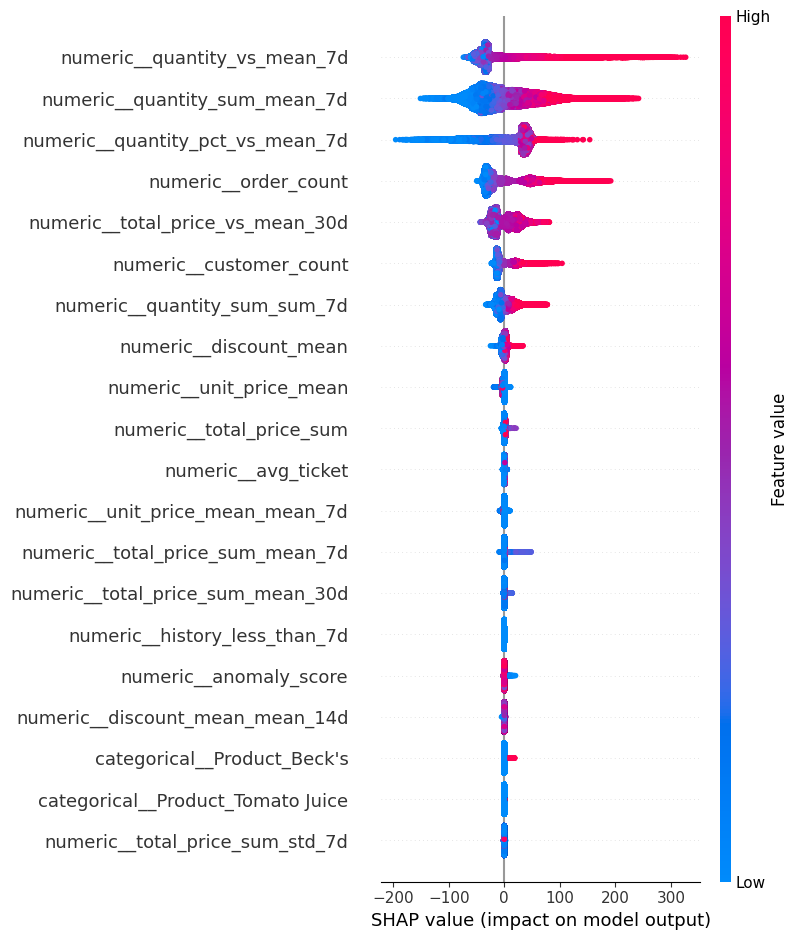

<Figure size 640x480 with 0 Axes>

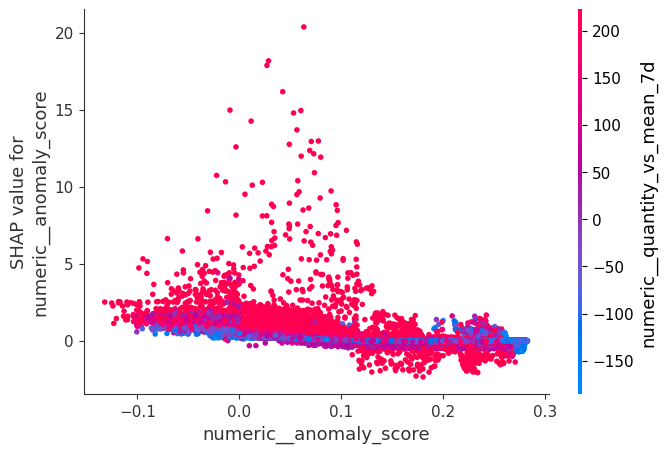

In [16]:
# ---------------------------------------------------------
# 3.1 Summary Plot
# ---------------------------------------------------------
plt.figure()
shap_interpreter.plot_summary(df_test_anomaly, plot_type="dot")

# ---------------------------------------------------------
# 3.2 Dependence Plot do anomaly_score
# ---------------------------------------------------------
# Ideal para verificar se existe "threshold" no impacto do anomaly_score
plt.figure()
shap_interpreter.plot_dependence(
    df=df_test_anomaly,
    feature_name="anomaly_score",
    interaction_index="auto"
)

In [17]:
# ---------------------------------------------------------
# 3.3 Importância global
# ---------------------------------------------------------
importance_df = shap_interpreter.get_feature_importance(df_test_anomaly)
display(importance_df.head(15))


,feature,mean_abs_shap
0,numeric__quantity_vs_mean_7d,42.508595
1,numeric__quantity_sum_mean_7d,41.473451
2,numeric__quantity_pct_vs_mean_7d,38.206664
3,numeric__order_count,34.636829
4,numeric__total_price_vs_mean_30d,18.679632
5,numeric__customer_count,15.100460
6,numeric__quantity_sum_sum_7d,10.609028
7,numeric__discount_mean,2.794836
8,numeric__unit_price_mean,1.405567
9,numeric__total_price_sum,1.170458


In [18]:
print([df_test_anomaly.columns.str.contains("anomaly", case=False, na=False)])

[array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False,  True,
        True,  True])]


d:\PROJETOS\git_repo\BEVERAGE-SALES\_venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\PROJETOS\git_repo\BEVERAGE-SALES\_venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


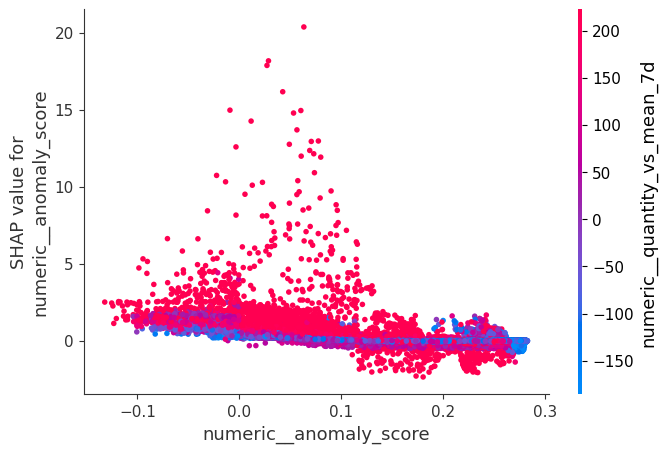

,quantity_sum,pred_baseline,pred_hybrid,baseline_abs_error,hybrid_abs_error,error_reduction
204569,867.0,781.090816,828.914603,85.909184,38.085397,47.823787
804841,1115.0,1023.376032,1070.357053,91.623968,44.642947,46.981022
195524,1074.0,1131.467933,1085.959774,57.467933,11.959774,45.508158


In [19]:
# ---------------------------------------------------------
# 1) gerar predições
# ---------------------------------------------------------
df_eval = df_test_anomaly.copy()

# baseline_model: instância de LightGBMRegressorBaseLine
df_eval["pred_baseline"] = baseline_model.predict(df_eval)

# pipeline_hybrid: pipeline sklearn do modelo híbrido
df_eval["pred_hybrid"] = hybrid_model.predict(df_eval)

TARGET_COL = "quantity_sum"
BASELINE_PRED_COL = "pred_baseline"
HYBRID_PRED_COL = "pred_hybrid"

# ---------------------------------------------------------
# 2) SHAP do modelo híbrido
# ---------------------------------------------------------
shap_interpreter = LightGBMShapInterpreterU(hybrid_model.best_model)

shap_interpreter.plot_dependence(
    df=df_eval,
    feature_name="anomaly_score",
    interaction_index="auto"
)

critical_cases = shap_interpreter.find_critical_corrections(
    df=df_eval,
    y_true_col=TARGET_COL,
    baseline_pred_col=BASELINE_PRED_COL,
    hybrid_pred_col=HYBRID_PRED_COL,
    top_n=3
)

display(
    critical_cases[
        [
            TARGET_COL,
            BASELINE_PRED_COL,
            HYBRID_PRED_COL,
            "baseline_abs_error",
            "hybrid_abs_error",
            "error_reduction"
        ]
    ]
)




Critical case index: 204569
Actual: 867.0000
Baseline prediction: 781.0908
Hybrid prediction: 828.9146
Error reduction: 47.8238


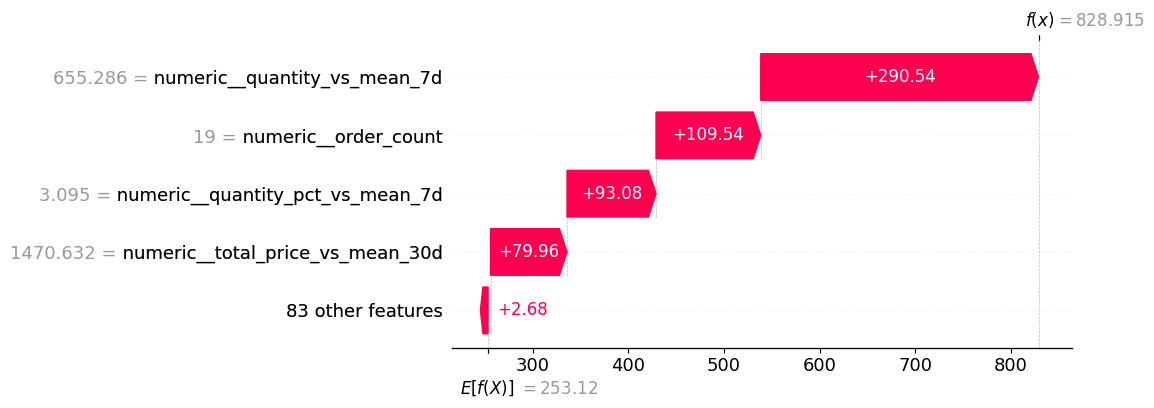


Critical case index: 804841
Actual: 1115.0000
Baseline prediction: 1023.3760
Hybrid prediction: 1070.3571
Error reduction: 46.9810


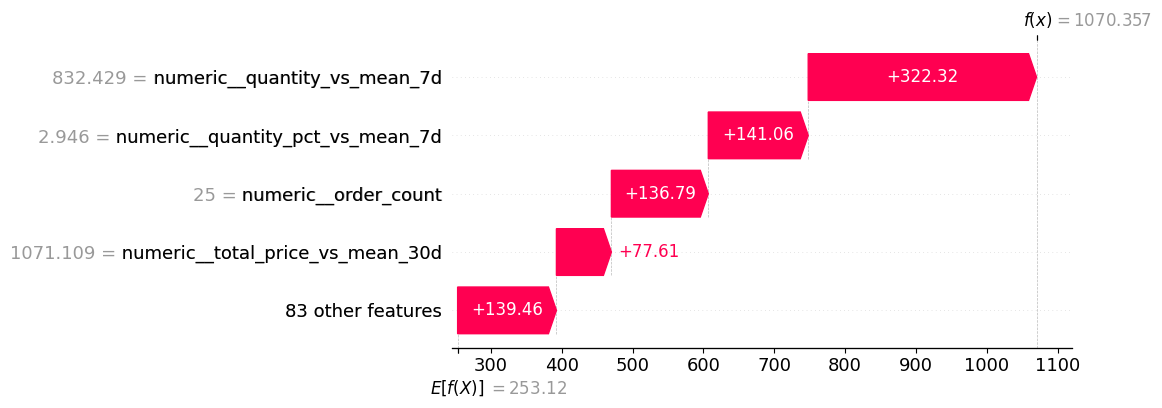


Critical case index: 195524
Actual: 1074.0000
Baseline prediction: 1131.4679
Hybrid prediction: 1085.9598
Error reduction: 45.5082


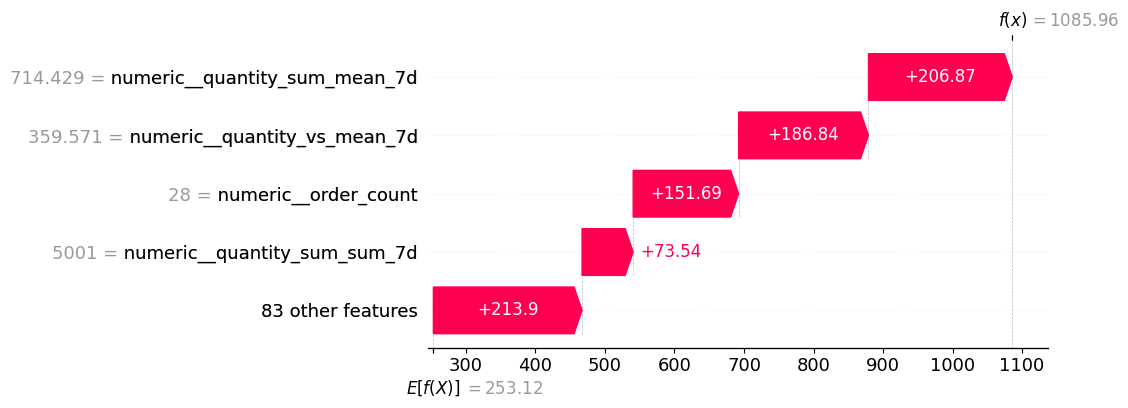

[{'row_index': 204569,
  'actual': 867.0,
  'baseline_prediction': 781.0908155003805,
  'hybrid_prediction': 828.9146029433183,
  'error_reduction': 47.82378744293783},
 {'row_index': 804841,
  'actual': 1115.0,
  'baseline_prediction': 1023.3760316922204,
  'hybrid_prediction': 1070.3570533322236,
  'error_reduction': 46.98102164000318},
 {'row_index': 195524,
  'actual': 1074.0,
  'baseline_prediction': 1131.4679325129669,
  'hybrid_prediction': 1085.9597741177279,
  'error_reduction': 45.50815839523898}]

In [21]:
shap_interpreter.plot_waterfall_for_critical_cases(
    X_df=df_eval,
    analysis_df=df_eval,
    y_true_col="quantity_sum",
    baseline_pred_col="pred_baseline",
    hybrid_pred_col="pred_hybrid",
    top_n=3,
    max_display=5
)